# IMPORTAR BIBLIOTECAS

In [1]:
# Bibliotecas utilizadas
import colorsys
import holidays
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
import pytz
import seaborn as sns
import time
import warnings
from plotly.subplots import make_subplots
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL, MSTL, seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from typing import cast, Tuple, Literal, Optional, Dict, Union

warnings.filterwarnings('ignore')

# 0. FUNÇÕES AUXILIARES

In [2]:
# Função para gerar cores distintas
def gerar_cores(n, hue_start=0.0, hue_end=0.85):
    """
    Gera uma lista de cores hexadecimais distintas usando o espaço de cor HSV.
    As cores são distribuídas uniformemente no intervalo de matiz especificado.

    Parâmetros
    ----------
    n : int
        Número de cores distintas a serem geradas.
    hue_start : float, opcional
        Matiz inicial no espaço HSV (0.0 a 1.0), padrão é 0.0.
    hue_end : float, opcional
        Matiz final no espaço HSV (0.0 a 1.0), padrão é 0.85.

    Retorno
    -------
    list[str]
        Lista de strings de cores em formato hexadecimal, ex: ['#ff0000', '#00ff00', ...].
    """
    colors = []
    if n <= 1:
        return ['#ff0000']  # Retorna vermelho padrão para 1 ou 0 cores requisitadas
    for i in range(n):
        # Calcula o valor da matiz distribuído uniformemente entre hue_start e hue_end
        hue = hue_start + (hue_end - hue_start) * i / max(n - 1, 1)
        saturation = 0.9  # Saturação para cores vivas
        value = 0.9       # Valor para alto brilho
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)  # Converte HSV para RGB normalizado (0-1)
        # Converte RGB para formato hexadecimal de cor
        hex_color = '#{:02x}{:02x}{:02x}'.format(
            int(rgb[0]*255),
            int(rgb[1]*255),
            int(rgb[2]*255)
        )
        colors.append(hex_color)

    return colors

In [3]:
# Função para deslocar timestamps UTC para fuso horário fixo ignorando DST
def deslocar_utc_para_fuso_fixo(
    df: pd.DataFrame, 
    tz_str: str, 
    coluna_datetime: str | None = None, 
    reference_date: str = '2025-01-01', 
    keep_tz: bool = False
) -> pd.DataFrame:
    """
    Ajusta timestamps UTC para um fuso horário fixo, ignorando horário de verão (DST).
    Cria coluna 'DST' indicando se cada timestamp original está em horário de verão.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame com índice datetime ou coluna datetime a ser ajustada.
    tz_str : str
        Nome do fuso horário fixo, ex: 'America/Sao_Paulo'.
    coluna_datetime : str ou None, opcional
        Nome da coluna datetime se for ajustada uma coluna, caso contrário ajusta o índice.
    reference_date : str, opcional
        Data de referência para cálculo do offset fixo UTC (formato 'YYYY-MM-DD').
    keep_tz : bool, opcional
        Se True, mantém informação de fuso no índice/coluna; senão retorna datetime naïve.

    Retorno
    -------
    pd.DataFrame
        DataFrame com índice ou coluna ajustada e coluna 'DST' indicando horário de verão.
    """

    timezone = pytz.timezone(tz_str)
    df = df.copy()

    def is_dst_utc(dt_utc):
        # Garante datetime-aware UTC para a data
        if dt_utc.tzinfo is None:
            dt_utc = dt_utc.tz_localize('UTC')
        else:
            dt_utc = dt_utc.tz_convert('UTC')
        dt_local = dt_utc.astimezone(timezone)
        return bool(dt_local.dst() != pd.Timedelta(0))  # True se DST ativo

    # Cria coluna DST avaliando horário de verão com base no timestamp original UTC
    if coluna_datetime is None:
        timestamps_utc = pd.to_datetime(df.index)
        df['DST'] = timestamps_utc.map(is_dst_utc)
    else:
        timestamps_utc = pd.to_datetime(df[coluna_datetime])
        df['DST'] = timestamps_utc.map(is_dst_utc)

    # Calcula offset fixo UTC ignorando DST na data de referência
    reference_timestamp = pd.to_datetime(reference_date)
    if reference_timestamp.tzinfo is None:
        reference_timestamp = reference_timestamp.tz_localize('UTC')
    else:
        reference_timestamp = reference_timestamp.tz_convert('UTC')

    fixed_offset = reference_timestamp.astimezone(timezone).utcoffset()
    if fixed_offset is None:
        raise ValueError(f"Não foi possível determinar offset UTC para {tz_str!r} em {reference_date!r}.")

    offset_timedelta = pd.Timedelta(fixed_offset)

    def aplicar_deslocamento(data_serie):
        # Converte para datetime naïve em UTC para operar soma do offset fixo
        datetime_utc_naive = pd.to_datetime(data_serie, utc=True).dt.tz_localize(None)
        datetime_shifted = datetime_utc_naive + offset_timedelta
        if keep_tz:
            return datetime_shifted.dt.tz_localize(timezone)
        else:
            return datetime_shifted

    # Aplica deslocamento fixo para índice ou coluna especificada
    if coluna_datetime is None:
        index_datetime_utc_naive = pd.to_datetime(df.index, utc=True).tz_localize(None)
        index_shifted = index_datetime_utc_naive + offset_timedelta
        df.index = index_shifted.tz_localize(timezone) if keep_tz else index_shifted
    else:
        df[coluna_datetime] = aplicar_deslocamento(df[coluna_datetime])

    return df

In [4]:
# Função para plotar séries temporais excluindo coluna DST
def plotar_scatter_sem_dst(df: pd.DataFrame) -> None:
    """
    Plota séries temporais para todas as colunas numéricas do DataFrame,
    excetuando a coluna 'DST', usando cores geradas pela função global 'gerar_cores'.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame com índice datetime e colunas numéricas para plotagem.

    Retorno
    -------
    None
        Exibe gráfico interativo.
    """
    # Seleciona colunas numéricas ignorando 'DST'
    colunas = [col for col in df.select_dtypes(include='number').columns if col.upper() != 'DST']

    if not colunas:
        raise ValueError("Nenhuma coluna numérica para plotar, excluindo 'DST'.")

    # Usa a função global para gerar cores
    cores = gerar_cores(len(colunas))

    fig = go.Figure()

    # Adiciona as séries ao gráfico com cores distintas
    for cor, coluna in zip(cores, colunas):
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df[coluna],
            mode='lines',
            name=coluna,
            line=dict(color=cor)
        ))

    fig.update_layout(
        title="Séries Temporais dos Dados",
        xaxis_title="Data",
        yaxis_title="Valor",
        width=1200,
        height=600,
        legend_title="Colunas"
    )

    fig.show()

In [5]:
# Função para plotar coluna DST
def plotar_scatter_dst(df: pd.DataFrame) -> None:
    """
    Plota gráfico de linha indicando a presença de Horário de Verão (DST) ao longo do tempo,
    com 1 representando DST ativo e 0 inativo.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo a coluna 'DST' e índice datetime.

    Retorno
    -------
    None
        Exibe o gráfico interativo.
    
    Levanta
    ------
    ValueError
        Caso o DataFrame não possua a coluna 'DST'.
    """
    # Verifica se a coluna 'DST' existe no DataFrame
    if 'DST' not in df.columns:
        raise ValueError("DataFrame não possui a coluna 'DST'")

    # Obtém a cor para o gráfico utilizando função global de geração de cores
    color_map_dst = gerar_cores(1)[0]

    # Cria figura plotly para série temporal do indicador DST
    fig_dst = go.Figure()
    fig_dst.add_trace(go.Scatter(
        x=df.index,
        y=df['DST'].astype(int),  # Converte boolean para 0 e 1
        mode='lines',
        name='DST (1=Sim, 0=Não)',
        line=dict(color=color_map_dst, width=2)
    ))

    # Configura layout com títulos e dimensões
    fig_dst.update_layout(
        title="Indicador de Horário de Verão (DST)",
        xaxis_title="Data",
        yaxis_title="DST (1=Sim, 0=Não)",
        height=400,
        width=1200,
    )

    # Exibe gráfico interativo
    fig_dst.show()

In [6]:
# Função para plotar violin plot por período
def plotar_violin_por_periodo(df: pd.DataFrame, coluna_interesse: str) -> None:
    """
    Plota violin plot da coluna de interesse para as janelas temporais
    últimos 3, 6, 12 meses e período completo, extraídas dentro da função.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame completo com índice datetime.
    coluna_interesse : str
        Nome da coluna para análise e plotagem.

    Retorno
    -------
    None
        Exibe o gráfico interativo.
    """

    # Extrai janelas temporais dentro da função
    df_3M = df[coluna_interesse].last('3M').to_frame()
    df_6M = df[coluna_interesse].last('6M').to_frame()
    df_12M = df[coluna_interesse].last('12M').to_frame()
    df_completo = df[coluna_interesse].to_frame()

    # Combina os dados para plotagem com marcação do período
    df_concat = pd.concat([
        pd.DataFrame({coluna_interesse: df_3M[coluna_interesse], 'Período': 'Últimos 3 meses'}),
        pd.DataFrame({coluna_interesse: df_6M[coluna_interesse], 'Período': 'Últimos 6 meses'}),
        pd.DataFrame({coluna_interesse: df_12M[coluna_interesse], 'Período': 'Últimos 12 meses'}),
        pd.DataFrame({coluna_interesse: df_completo[coluna_interesse], 'Período': 'Completo'})
    ], ignore_index=True)

    # Gera cores distintas para cada período (função global)
    cores = gerar_cores(len(df_concat['Período'].unique()))
    color_map = dict(zip(df_concat['Período'].unique(), cores))

    # Monta o gráfico violin plot por período
    fig = go.Figure()
    for periodo, cor in color_map.items():
        fig.add_trace(go.Violin(
            y=df_concat.loc[df_concat['Período'] == periodo, coluna_interesse],
            name=periodo,
            box_visible=True,
            meanline_visible=True,
            line_color='black',
            fillcolor=cor,
            opacity=0.4
        ))

    # Ajusta detalhes do layout
    fig.update_layout(
        title=f"Violin Plot da coluna {coluna_interesse} por período",
        width=1200,
        yaxis_title=coluna_interesse
    )

    # Exibe o gráfico
    fig.show()

In [7]:
def gerar_features_temporais(
    data: pd.Series | pd.DataFrame
) -> pd.DataFrame:
    """
    Extrai e acrescenta características temporais comuns a partir do índice datetime de uma série ou DataFrame.
    
    Parâmetros
    ----------
    data : pd.Series ou pd.DataFrame
        Série ou DataFrame temporal com índice do tipo datetime.

    Retorno
    -------
    pd.DataFrame
        DataFrame contendo as colunas originais e as seguintes colunas temporais adicionais:
        - 'ANO': ano extraído do índice
        - 'MES': mês numérico (1 a 12)
        - 'MES_str': abreviação do mês em português
        - 'DIA_str': abreviação do dia da semana em português
        - 'SEMANA': número da semana ISO do ano
        - 'HORA': hora do dia (0 a 23)
        - 'DIA': dia da semana númerico (0=Segunda, 6=Domingo)
        - 'ANO_MES': string formatada 'AAAA_MM'
        
    Descrição
    ----------
    A função adapta a entrada para DataFrame (se for uma série) e popula colunas para facilitar análises temporais,
    como análises sazonais, agrupamentos por meses, dias e horas.

    Exemplo
    -------
    >>> df_features = gerar_features_temporais(minha_serie_temporal)
    """
    dt_index = pd.DatetimeIndex(data.index)

    # Converter a entrada para DataFrame para facilitar manipulação
    if isinstance(data, pd.Series):
        df = data.to_frame(name=data.name)
    else:
        df = data.copy()

    # Extrai componentes primários de tempo
    df['ANO'] = dt_index.year
    df['MES'] = dt_index.month

    # Mapas para abreviação de meses e dias em português
    mapa_meses = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
                  7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
    df['MES_str'] = df['MES'].map(mapa_meses)

    # Abreviação dos dias da semana: de inglês para português
    df['DIA_str'] = dt_index.strftime('%a')
    mapa_dias = {'Mon': 'Seg', 'Tue': 'Ter', 'Wed': 'Qua', 'Thu': 'Qui',
                 'Fri': 'Sex', 'Sat': 'Sab', 'Sun': 'Dom'}
    df['DIA_str'] = df['DIA_str'].map(mapa_dias)

    # Número da semana ISO, hora do dia e índice numérico do dia da semana
    df['SEMANA'] = dt_index.isocalendar().week
    df['HORA'] = dt_index.hour
    df['DIA'] = dt_index.dayofweek

    # Ano e mês concatenados para fácil agrupamento mensal
    df['ANO_MES'] = dt_index.strftime('%Y_%m')

    return df


In [8]:
def plotar_scatter_anual(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota gráfico de linha para visualizar a sazonalidade anual de uma série temporal,
    exibindo a média mensal agrupada por ano.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Texto usado como nome da medida para títulos e eixo Y (ex.: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o gráfico sazonal anual preparado.

    Descrição
    -----------
    A função agrega por mês e ano, plota um traço para cada ano com cor distinta.
    O título do gráfico e do eixo Y são definidos dinamicamente com base em nome_medida.
    """

    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai apenas o texto antes de " [" para título
    nome_base = nome_medida.split(" [")[0]

    # Agrupa por mês e ano, calculando média mensal por ano
    df_scatter_anual = df[['MES', 'ANO', col_name]].dropna().groupby(['MES', 'ANO']).mean().reset_index()
    anos = sorted(df_scatter_anual['ANO'].unique())

    # Gera cores distintas para cada ano
    color_map_anos = gerar_cores(len(anos))

    fig_scatter_anual = go.Figure()

    # Adiciona uma linha para cada ano
    for i, ano in enumerate(anos):
        df_ano = df_scatter_anual[df_scatter_anual['ANO'] == ano]
        fig_scatter_anual.add_trace(go.Scatter(
            x=df_ano['MES'],
            y=df_ano[col_name],
            mode='lines+markers',
            name=str(ano),
            line=dict(color=color_map_anos[i], width=3)
        ))

    # Configurações do layout, com título dinâmico e eixo Y dinamizado
    fig_scatter_anual.update_layout(
        title=f"Gráfico Sazonal - {nome_base} Mensal - {col_name}",
        xaxis=dict(
            title='Mês',
            tickmode='array',
            tickvals=list(range(1, 13)),
            ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                      'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
        ),
        yaxis=dict(title=nome_medida),
        legend_title_text='Ano',
        height=700,
        width=1200
    )

    return fig_scatter_anual

In [9]:
def plotar_scatter_semanal(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota gráfico de linha para visualizar a sazonalidade semanal de uma série temporal,
    exibindo a média diária agrupada por mês e ordenada pelo dia da semana.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Texto usado para o nome da medida, utilizado no título e no eixo Y
        (ex: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o gráfico sazonal semanal preparado.

    Descrição
    ----------
    A função utiliza features temporais para agrupar por dia da semana e mês,
    adicionando traços coloridos para cada mês. O título é gerado dinamicamente a partir do nome da medida.
    """

    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai apenas o texto anterior ao " [" para o título
    nome_base = nome_medida.split(" [")[0]

    # Agrupa por dia da semana, mês e número do dia, calculando média
    df_scatter_semanal = df[['MES_str', 'DIA_str', col_name, 'DIA']].dropna() \
        .groupby(['DIA_str', 'MES_str', 'DIA']).mean().reset_index()
    df_scatter_semanal = df_scatter_semanal.sort_values(by='DIA')

    # Lista de meses presentes no dataframe em ordem calendarial
    meses = [mes for mes in ['Jan','Fev','Mar','Abr','Mai','Jun',
                            'Jul','Ago','Set','Out','Nov','Dez'] if mes in df_scatter_semanal['MES_str'].values]

    # Gera cores distintas para cada mês
    color_map_meses = gerar_cores(len(meses))

    # Ordem dos dias da semana para eixo x
    order_days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
    df_scatter_semanal['DIA_str'] = pd.Categorical(df_scatter_semanal['DIA_str'], categories=order_days, ordered=True)
    df_scatter_semanal = df_scatter_semanal.sort_values(by='DIA_str')

    fig_scatter_semanal = go.Figure()

    # Adiciona uma linha para cada mês
    for i, mes in enumerate(meses):
        df_mes = df_scatter_semanal[df_scatter_semanal['MES_str'] == mes]
        fig_scatter_semanal.add_trace(go.Scatter(
            x=df_mes['DIA_str'],
            y=df_mes[col_name],
            mode='lines+markers',
            name=mes,
            line=dict(color=color_map_meses[i], width=3)
        ))

    # Configurações de layout com título e eixo Y dinâmicos
    fig_scatter_semanal.update_layout(
        title=f"Gráfico Sazonal - {nome_base} Semanal por Mês - {col_name}",
        xaxis=dict(
            title='Dia da Semana',
            categoryorder='array',
            categoryarray=order_days,
            ticklabelmode='period',
            tickson='labels'
        ),
        yaxis_title=nome_medida,
        legend_title_text='Mês',
        height=700,
        width=1200,
        margin=dict(l=0, r=0, t=80, b=40)
    )

    return fig_scatter_semanal

In [10]:
def plotar_scatter_diario(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota gráfico de linha para visualizar a sazonalidade diária de uma série temporal,
    exibindo a média horária agrupada por dia da semana.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Texto usado como nome da medida para título do gráfico e eixo Y (ex.: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o gráfico de sazonalidade diária preparado.

    Descrição
    ----------
    A função calcula a média horária para cada dia da semana, plota um traço por dia usando cor distinta.
    O título do gráfico e o eixo Y são gerados dinamicamente com base no nome da medida.
    """
    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai apenas o texto anterior ao " [" para compor o título
    nome_base = nome_medida.split(" [")[0]

    # Agrupa por hora e dia da semana abreviado, calculando média
    df_scatter_dario = df[['HORA', 'DIA_str', col_name]].dropna().groupby(['HORA', 'DIA_str']).mean().reset_index()

    # Sequência lógica dos dias da semana
    order_days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
    df_scatter_dario['DIA_str'] = pd.Categorical(df_scatter_dario['DIA_str'], categories=order_days, ordered=True)
    df_scatter_dario = df_scatter_dario.sort_values(by=['DIA_str', 'HORA'])

    # Lista dos dias para cores distintas
    dias_unicos = list(df_scatter_dario['DIA_str'].cat.categories)
    color_map_dias = gerar_cores(len(dias_unicos))

    fig_scatter_dario = go.Figure()

    # Adiciona uma linha para cada dia da semana
    for i, dia in enumerate(dias_unicos):
        df_dia = df_scatter_dario[df_scatter_dario['DIA_str'] == dia]
        fig_scatter_dario.add_trace(go.Scatter(
            x=df_dia['HORA'],
            y=df_dia[col_name],
            mode='lines+markers',
            name=dia,
            line=dict(color=color_map_dias[i], width=3)
        ))

    # Configuração do layout do gráfico, com título dinâmico e eixo Y personalizado
    fig_scatter_dario.update_layout(
        title=f"Gráfico Sazonal - {nome_base} Diário por Hora - {col_name}",
        xaxis=dict(title='Hora', dtick=1, range=[0, 23]),
        yaxis=dict(title=nome_medida),
        legend_title_text='Dia da Semana',
        height=700,
        width=1200
    )

    return fig_scatter_dario

In [11]:
def plotar_box_anual(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota box plot anual para visualizar a distribuição mensal de uma série temporal,
    agrupando por mês e destacando a média e desvio padrão.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Nome da medida, usado no título e eixo Y do gráfico (ex: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o box plot anual preparado.

    Descrição
    ----------
    A função agrupa valores mensais, gera um box plot para cada mês do ano, com cores distintas.
    O título é dinâmico, refletindo a medida analisada e o nome da série.
    """
    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai nome base anterior ao " [" para compor o título
    nome_base = nome_medida.split(" [")[0]

    # Prepara DataFrame anual categorizando e ordenando meses
    df_anual = df[['MES', 'ANO', 'MES_str', col_name]].dropna()
    df_anual['MES_str'] = pd.Categorical(
        df_anual['MES_str'],
        categories=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
        ordered=True
    )
    df_anual = df_anual.sort_values(by='MES')

    # Gera paleta de cores para os meses
    color_palette = gerar_cores(len(df_anual['MES_str'].cat.categories))

    fig_box_anual = go.Figure()
    for i, mes in enumerate(df_anual['MES_str'].cat.categories):
        df_mes = df_anual[df_anual['MES_str'] == mes]
        fig_box_anual.add_trace(go.Box(
            y=df_mes[col_name],
            name=mes,
            boxmean='sd',
            marker_color=color_palette[i]
        ))

    fig_box_anual.update_layout(
        title=f"Box Plot Anual - {nome_base} Mensal - {col_name}",
        xaxis_title='Mês',
        yaxis_title=nome_medida,
        height=700,
        width=1200
    )
    return fig_box_anual


In [12]:
def plotar_box_semanal(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota box plot semanal para visualizar a distribuição da medida por dia da semana,
    destacando média e desvio padrão.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Nome da medida para título e eixo Y (ex: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o box plot semanal preparado.

    Descrição
    ----------
    Agrupa e plota a distribuição de valores por dia da semana, atribuindo cor distinta para cada dia.
    O título é dinâmico, extraindo o nome da medida para maior clareza.
    """
    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai nome base para o título antes de " ["
    nome_base = nome_medida.split(" [")[0]

    df_semanal = df[['DIA_str', 'DIA', col_name]].dropna()
    order_days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
    df_semanal['DIA_str'] = pd.Categorical(df_semanal['DIA_str'], categories=order_days, ordered=True)
    df_semanal = df_semanal.sort_values(by='DIA')

    color_palette = gerar_cores(len(df_semanal['DIA_str'].cat.categories))

    fig_box_semanal = go.Figure()
    for i, dia in enumerate(df_semanal['DIA_str'].cat.categories):
        df_dia = df_semanal[df_semanal['DIA_str'] == dia]
        fig_box_semanal.add_trace(go.Box(
            y=df_dia[col_name],
            name=dia,
            boxmean='sd',
            marker_color=color_palette[i]
        ))

    fig_box_semanal.update_layout(
        title=f"Box Plot Semanal - {nome_base} por Dia da Semana - {col_name}",
        xaxis_title='Dia da Semana',
        yaxis_title=nome_medida,
        height=700,
        width=1200
    )
    return fig_box_semanal


In [13]:
def plotar_box_diario(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota box plot diário para visualizar a distribuição da medida por hora,
    destacando média e desvio padrão, permitindo personalização da medida analisada.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Nome da medida para título do gráfico e eixo Y (ex: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o box plot diário preparado.

    Descrição
    ----------
    Agrupa e plota a distribuição dos valores por hora do dia. O título e o eixo Y são dinâmicos,
    extraindo o nome da medida para maior clareza conforme o contexto da análise.
    """
    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai nome base antes de " [" para compor o título
    nome_base = nome_medida.split(" [")[0]

    df_diario = df[['HORA', col_name]].dropna()
    horas = sorted(df_diario['HORA'].unique())

    color_palette = gerar_cores(len(horas))

    fig_box_diario = go.Figure()
    for i, hora in enumerate(horas):
        df_hora = df_diario[df_diario['HORA'] == hora]
        fig_box_diario.add_trace(go.Box(
            y=df_hora[col_name],
            name=str(hora),
            boxmean='sd',
            marker_color=color_palette[i]
        ))

    fig_box_diario.update_layout(
        title=f"Box Plot Diário - {nome_base} por Hora - {col_name}",
        xaxis_title='Hora',
        yaxis_title=nome_medida,
        height=700,
        width=1200
    )
    return fig_box_diario


In [14]:
def plotar_box_ano_mes(
    series: pd.Series,
    nome_medida: str = "Consumo [MW]"
) -> go.Figure:
    """
    Plota box plot para visualizar a distribuição da medida por cada combinação de ano e mês,
    destacando média e desvio padrão.

    Parâmetros
    ----------
    series : pd.Series
        Série temporal com índice datetime e nome definido para a coluna de valores.
    nome_medida : str, opcional
        Nome da medida para título do gráfico e eixo Y (ex: 'Consumo [MW]', 'Preço [R$]', 'Demanda [MW]').

    Retorno
    -------
    go.Figure
        Objeto figure do Plotly com o box plot por Ano-Mês preparado.

    Descrição
    ----------
    Agrupa em caixas (boxplots) os valores de cada período Ano-Mês e colore cada caixa distintamente.
    O título e o eixo Y do gráfico são dinâmicos, refletindo a medida parametrizada.
    """
    df = gerar_features_temporais(series)
    col_name = series.name

    # Extrai nome base antes de " [" para o título
    nome_base = nome_medida.split(" [")[0]

    df_am = df[['ANO_MES', 'ANO', 'MES', col_name]].dropna()
    df_am = df_am.sort_values(by=['ANO', 'MES'])
    anos_meses = df_am['ANO_MES'].unique()

    color_palette = gerar_cores(len(anos_meses))

    fig_box_am = go.Figure()
    for i, ym in enumerate(anos_meses):
        df_am_subset = df_am[df_am['ANO_MES'] == ym]
        fig_box_am.add_trace(go.Box(
            y=df_am_subset[col_name],
            name=ym,
            boxmean='sd',
            marker_color=color_palette[i]
        ))

    fig_box_am.update_layout(
        title=f"Box Plot - {nome_base} por Ano-Mês - {col_name}",
        xaxis_title='Ano-Mês',
        yaxis_title=nome_medida,
        height=700,
        width=1200
    )
    return fig_box_am


# 1. IMPORTAÇÃO DOS DADOS

In [15]:
def preparar_dados_temporais(
    caminho_csv: str,
    coluna_interesse: list | str | None = None,
    coluna_tempo: str = "Timestamp",
    freq: str = "h",
    tz_fixo: str = "America/Sao_Paulo",
    plot: bool = True,
) -> pd.DataFrame:
    """
    Carrega e prepara uma série temporal a partir de arquivo CSV.

    Parâmetros
    ----------
    caminho_csv : str
        Caminho para o arquivo CSV com dados temporais.
    coluna_interesse : list | str | None, opcional
        Nome(s) da(s) coluna(s) de dados que se deseja extrair.
    coluna_tempo : str, opcional
        Nome da coluna temporal a ser usada como índice.
    freq : str, opcional
        Frequência da série temporal a ser garantida (ex.: 'h' para horário).
    tz_fixo : str, opcional
        Fuso horário fixo para ajuste do índice datetime, sem horário de verão.
    plot : bool, opcional
        Se True, plota a coluna DST após o ajuste do fuso horário.

    Retorno
    -------
    pd.DataFrame
        DataFrame com índice datetime ajustado, frequência corrigida e apenas a coluna de interesse.
    """
    
    # Cabeçalho
    print("="*100)
    print(f"{'CARREGAMENTO E PREPARAÇÃO DE DADOS TEMPORAIS':^100}")
    print("="*100, "\n")
    
    # Carrega o CSV para DataFrame pandas
    df = pd.read_csv(caminho_csv)

    # Valida se a coluna temporal existe no DataFrame
    if coluna_tempo not in df.columns:
        raise ValueError(f"Coluna de tempo '{coluna_tempo}' não encontrada no CSV.")

    # Define a coluna temporal como índice do DataFrame
    df = df.set_index(coluna_tempo)

    # Se coluna_interesse for None, mantém todas
    if coluna_interesse is None:
        pass  # mantém todas as colunas
    else:
        # Convete string para lista
        if isinstance(coluna_interesse, str):
            coluna_interesse = [coluna_interesse]

        # Valida se todas as colunas estão no DataFrame
        faltando = [col for col in coluna_interesse if col not in df.columns]
        if faltando:
            raise ValueError(f"Colunas não encontradas: {faltando}")

        # Mantém apenas as colunas indicadas
        df = df[coluna_interesse]
        
        # Liberar variável temporária após uso
        del faltando
    
    # Apresenta as primeiras linhas do DataFrame carregado
    print(">>> PRÉ-VISUALIZAÇÃO DOS DADOS CARREGADOS:\n")
    print(df.head(), "\n")

    # Converte o índice para datetime no fuso UTC
    df.index = pd.to_datetime(df.index, utc=True)

    # Ajusta a frequência temporal (ex.: horário) preenchendo lacunas temporais vazias
    df = df.asfreq(freq)

    # Aplica ajuste do índice para o fuso horário fixo, removendo horário de verão e criando flag DST
    df = deslocar_utc_para_fuso_fixo(df, tz_fixo)
    
    # Apresenta as primeiras linhas do DataFrame preparado
    print(">>> PRÉ-VISUALIZAÇÃO DOS DADOS PREPARADOS SEM HORÁRIO DE VERÃO (DST):\n")
    print(df.head(), "\n")
    
    # Apresentar gráficos se solicitado
    if plot:
        plotar_scatter_sem_dst(df)
        plotar_scatter_dst(df)

    # Retorna o DataFrame preparado
    return df

# 2. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

In [16]:
def analisar_estatisticas(
    df: pd.DataFrame,
    limite_nulos_pct: float = 20,
    plot: bool = False
) -> pd.DataFrame:
    """
    Executa análise descritiva e verificação da qualidade dos dados em séries temporais.
    Remove colunas com excesso de valores nulos e ignora a coluna 'DST' no cálculo das estatísticas.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame temporal com índice datetime.
    limite_nulos_pct : float, opcional
        Percentual máximo tolerado de valores nulos por coluna antes de removê-la.

    Retorno
    -------
    pd.DataFrame
        DataFrame filtrado com colunas excluídas conforme critério de valores nulos.
    """
    
    # Início do relatório de análise
    print("="*100)
    print(f"{'ANÁLISE AGRUPADA DE DADOS E ESTATÍSTICAS DESCRITIVAS':^100}")
    print("="*100, "\n")

    # Cálculo e impressão dos valores nulos por coluna para avaliar qualidade dos dados
    nulls = df.isnull().sum()
    print(">>> VALORES NULOS POR COLUNA")
    print("\n".join(f"{col:<25}{val}" for col, val in nulls.items()))
    print(f"{'Número total:':<25}{nulls.sum()}\n")

    # Identificação e remoção de colunas que excedem percentual máximo de nulos definido
    colunas_para_remover = df.columns[nulls > (limite_nulos_pct / 100) * len(df)]
    print(">>> REMOÇÃO DE COLUNAS COM VALORES NULOS EXCESSIVOS")
    if len(colunas_para_remover):
        df = df.drop(columns=colunas_para_remover)
        print(f"Colunas removidas (>{limite_nulos_pct}% nulos): {list(colunas_para_remover)}")
        print(f"Número de valores nulos após remoção: {df.isnull().sum().sum()}\n")
    else:
        print("Nenhuma coluna removida por excesso de valores nulos.\n")

    # Análise da integridade temporal: duplicatas, perído, ordenação e lacunas na série temporal
    duplicados = df.index.duplicated().sum()
    inicio, fim = df.index.min(), df.index.max()
    ordenado = "Sim" if df.index.is_monotonic_increasing else "Não"
    date_range = pd.date_range(inicio, fim, freq='h')
    missing_dates = date_range.difference(pd.DatetimeIndex(df.index))

    print(">>> ANÁLISE DO ÍNDICE TEMPORAL")
    print(f"{'Número de timestamps duplicados:':<35}{duplicados}")
    print(f"{'Intervalo de datas:':<35}{inicio} à {fim}")
    print(f"{'O índice está ordenado?':<35}{ordenado}")
    print(f"{'Número de datas ausentes:':<35}{len(missing_dates)}")
    if len(missing_dates) > 0:
        print("Datas ausentes:")
        print("\n".join(f"  - {d}" for d in missing_dates))
    print()
    
    # Impressão das estatísticas descritivas para cada coluna, filtrando a coluna DST
    print(">>> ESTATÍSTICAS DESCRITIVAS COMPARATIVAS POR COLUNA")
    for coluna in df.columns:
        if coluna.upper() == 'DST':
            # Exclui a coluna DST da análise
            continue
        
        print(f"Tabela de estatísticas para a coluna: {coluna}")
        
        # Extrai janelas temporais para a coluna
        df_3M  = df[coluna].last('3M')
        df_6M  = df[coluna].last('6M')
        df_12M = df[coluna].last('12M')
        df_COM = df[coluna]
        
        # Calcula estatísticas descritivas para cada janela
        estat_3M  = df_3M.describe().rename(f"3M")
        estat_6M  = df_6M.describe().rename(f"6M")
        estat_12M = df_12M.describe().rename(f"12M")
        estat_COM = df_COM.describe().rename(f"COM")

        # Concatena resultados ajustando os sufixos para identificar os períodos
        comparacao = pd.concat([estat_3M, estat_6M, estat_12M, estat_COM], axis=1)

        # Configura o pandas para formatar floats com 2 casas decimais na exibição
        with pd.option_context('display.float_format', '{:,.2f}'.format):
            print(comparacao.to_string())
            
        # Plota violin plot para a coluna na janela completa, se habilitado
        if plot:
            plotar_violin_por_periodo(df_COM.to_frame(), coluna)
        
        print("-"*80)
    
    # Liberar variáveis temporárias após uso
    del nulls, colunas_para_remover
    del duplicados, inicio, fim, ordenado, date_range, missing_dates
    del df_3M, df_6M, df_12M, df_COM
    del estat_3M, estat_6M, estat_12M, estat_COM
    del comparacao

    # Retorna o DataFrame filtrado para uso posterior
    return df

In [17]:
def definir_janela_temporal(
    df: pd.DataFrame,
    janela: str = '12M'
) -> pd.DataFrame:
    """
    Retorna um DataFrame filtrado para os últimos X meses definidos pela janela temporal.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame temporal com índice datetime.
    janela : str
        String representando janela temporal suportada pelo pandas, ex: '3M', '6M', '12M'.

    Retorna:
    --------
    pd.DataFrame
        DataFrame filtrado conforme a janela temporal.
    """
    # Início da definição da janela temporal
    print("="*100)
    print(f"{'DEFINIÇÃO DA JANELA TEMPORAL PARA ANÁLISE':^100}")
    print("="*100, "\n")
    
    # Filtra o DataFrame para a janela temporal especificada
    df_filtrado = df.last(janela)
    print(f"\nDefinindo o conjunto de dados para os últimos {janela}: {df_filtrado.index.min()} à {df_filtrado.index.max()}\n")
    
    # Retorna o DataFrame filtrado
    return df_filtrado

# 3. ANÁLISE DA ESTRUTURA TEMPORAL

In [18]:
def testes_estacionariedade(
    serie: pd.Series,
    signif: float = 0.05
) -> Dict[str, Union[float, bool]]:
    """
    Executa os testes de estacionariedade ADF e KPSS na série temporal,
    apresentando os resultados com cabeçalhos e seguindo padrão de formatação

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal numérica para análise.
    signif : float, opcional
        Nível de significância para decisão dos testes. Default 0.05.

    Retorno
    -------
    dict
        Estatísticas, p-valores e decisões para ADF e KPSS.
    """

    # Cabeçalho formatado para identificação clara do teste
    print("="*100)
    print(f"{'TESTES DE ESTACIONARIEDADE (ADF e KPSS)':^100}")
    print("="*100, "\n")

    # Remove valores ausentes para evitar erro na execução dos testes
    serie_ok = serie.dropna()

    # Executa o teste Augmented Dickey-Fuller (ADF) e extrai resultados
    adf_stat, adf_pval, *_ = adfuller(serie_ok)

    # Executa o teste KPSS e extrai resultados. Converte para float explícito
    kpss_result = kpss(serie_ok, regression='c', nlags='auto')
    kpss_stat = float(kpss_result[0])
    kpss_pval = float(kpss_result[1])

    # Imprime os resultados formatados para melhor visualização
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"ADF p-value: {adf_pval:.4f}")
    print(f"ADF estacionário? : {'Sim' if adf_pval <= signif else 'Não'}\n")
    print(f"KPSS Statistic: {kpss_stat:.4f}")
    print(f"KPSS p-value: {kpss_pval:.4f}")
    print(f"KPSS estacionário? : {'Sim' if kpss_pval > signif else 'Não'}\n")

    # Retorna dados para uso em comparação e análise programática
    return {
        "ADF Statistic": float(adf_stat),
        "ADF p-value": float(adf_pval),
        "ADF Stationary?": bool(adf_pval <= signif),
        "KPSS Statistic": float(kpss_stat),
        "KPSS p-value": float(kpss_pval),
        "KPSS Stationary?": bool(kpss_pval > signif),
    }

In [19]:
def identificar_periodicidades_fft(
    serie: pd.Series,
    sampling_freq: float = 1.0,
    top_n: int = 3
) -> pd.DataFrame:
    """
    Identifica as principais frequências sazonais em uma série temporal utilizando FFT,
    exibindo os resultados com formatação e retornando as periodicidades mais relevantes.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal numérica para análise.
    sampling_freq : float, opcional
        Frequência da amostragem dos dados (exemplo: 1 para dados horários).
        Default: 1.0.
    top_n : int, opcional
        Número máximo de frequências mais relevantes a retornar.
        Default: 3.

    Retorno
    -------
    pd.DataFrame
        DataFrame com as frequências, períodos e potências das top_n componentes FFT.
    """

    # Cabeçalho formatado para identificação clara do teste na saída
    print("="*100)
    print(f"{'TESTE DE SAZONALIDADE VIA FFT':^100}")
    print("="*100, "\n")

    # Filtra valores ausentes para evitar erro na FFT
    serie_filtrada = serie.dropna()
    # Centraliza série para melhor representação FFT
    serie_centrada = serie_filtrada - serie_filtrada.mean()

    # Calcula FFT da série centrada
    fft_vals = np.fft.fft(serie_centrada)
    # Frequências associadas à FFT considerando frequência de amostragem
    fft_freq = np.fft.fftfreq(len(serie_centrada), d=1/sampling_freq)
    # Potência dos componentes da FFT (magnitude ao quadrado)
    power = np.abs(fft_vals) ** 2

    # Considera apenas frequências positivas relevantes para análise de periodicidade
    mask = fft_freq > 0
    freqs = fft_freq[mask]
    powers = power[mask]
    periods = 1 / freqs

    # Cria DataFrame com frequência, período e potência
    df_fft = pd.DataFrame({
        "Frequência": freqs,
        "Periodo": periods,
        "Potência": powers
    })

    # Ordena e mantem as top_n periodicidades mais potentes
    df_top = df_fft.sort_values(by="Potência", ascending=False).head(top_n)

    # Imprime os resultados principais com formatação para fácil leitura
    print(f">>> Principais periodicidades detectadas (top {top_n}):")
    print(df_top.to_string(index=False))

    return df_top

In [20]:
def calcular_corr_lags(
    serie: pd.Series,
    max_lag: int = 48,
    top_n: int = 5
) -> pd.DataFrame:
    """
    Calcula as correlações da série temporal com suas próprias defasagens (lags),
    e exibe apenas os top_n lags com maior valor absoluto de correlação.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal numérica para análise.
    max_lag : int, opcional
        Número máximo de lags a serem calculados. Default: 48.
    top_n : int, opcional
        Quantidade dos lags mais relevantes a mostrar. Default: 5.

    Retorno
    -------
    pd.DataFrame
        DataFrame com defasagens e coeficientes de correlação, ordenado por importância.
    """

    print("="*100)
    print(f"{'ANÁLISE DOS LAGS':^100}")
    print("="*100, "\n")

    serie_ok = serie.dropna()
    lags = range(1, max_lag + 1)
    corrs = [serie_ok.corr(serie_ok.shift(lag)) for lag in lags]

    df_lags = pd.DataFrame({
        "Lag": lags,
        "Correlacao": corrs
    })

    # Ordena pela magnitude absoluta da correlação para destacar os mais relevantes
    df_lags['abs_corr'] = df_lags['Correlacao'].abs()
    df_top = df_lags.sort_values(by='abs_corr', ascending=False).head(top_n).drop(columns='abs_corr')

    # Exibe os top_n lags mais relevantes
    print(f">>> Top {top_n} lags mais relevantes:")
    print(df_top.to_string(index=False))

    return df_lags

In [21]:
def analisar_acf(
    serie: pd.Series,
    lags: int = 48,
    alpha: float = 0.05,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Calcula e plota a função de autocorrelação (ACF) para a série temporal,
    exibindo os lags mais relevantes (maior módulo de autocorrelação),
    retornando as autocorrelações para análise.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal numérica para análise.
    lags : int, opcional
        Número máximo de defasagens a considerar. Default: 48.
    alpha : float, opcional
        Nível de significância para intervalo de confiança. Default: 0.05.
    top_n : int, opcional
        Quantidade de lags mais relevantes a exibir. Default: 10.

    Retorno
    -------
    pd.DataFrame
        DataFrame contendo lags, autocorrelações e intervalos de confiança,
        ordenado pelos lags mais relevantes (maior valor absoluto ACF).
    """

    print("="*100)
    print(f"{'ANÁLISE DE AUTOCORRELAÇÃO (ACF)':^100}")
    print("="*100, "\n")

    serie_ok = serie.dropna()

    resultados = acf(serie_ok, nlags=lags, alpha=alpha, fft=True)
    acf_vals, confint = resultados[:2]  # evita erro de desempacotamento do Pylance

    lags_array = np.arange(len(acf_vals))
    lower_conf = confint[:, 0]
    upper_conf = confint[:, 1]

    df_acf = pd.DataFrame({
        'Lag': lags_array,
        'ACF': acf_vals,
        'Lower_CI': lower_conf,
        'Upper_CI': upper_conf
    })

    # Ordena pelo valor absoluto da autocorrelação e seleciona top_n mais fortes
    df_top = df_acf.reindex(df_acf['ACF'].abs().sort_values(ascending=False).index).head(top_n)

    print(f">>> Top {top_n} lags mais relevantes (maior módulo ACF):")
    print(df_top.to_string(index=False))

    # Plot interativo (com todos os lags, visualizar a série completa)
    fig = go.Figure()
    fig.add_trace(go.Bar(x=lags_array, y=acf_vals, name='ACF', marker_color='blue'))
    fig.add_hline(y=0, line_dash="dash", line_color="black")
    fig.add_trace(go.Scatter(x=lags_array, y=lower_conf, mode='lines', line=dict(color='red', dash='dot'), name='Limite Inferior'))
    fig.add_trace(go.Scatter(x=lags_array, y=upper_conf, mode='lines', line=dict(color='red', dash='dot'), name='Limite Superior'))

    fig.update_layout(
        title="Função de Autocorrelação (ACF)",
        xaxis_title="Lag",
        yaxis_title="Autocorrelação",
        template='plotly_white',
        height=500
    )
    fig.show()

    return df_acf

In [22]:
def analisar_pacf(
    serie: pd.Series,
    lags: int = 48,
    alpha: float = 0.05,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Calcula e plota a função de autocorrelação parcial (PACF) para a série temporal,
    exibindo os lags mais relevantes (maior módulo de autocorrelação parcial),
    retornando os valores para análise.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal numérica para análise.
    lags : int, opcional
        Número máximo de defasagens a considerar. Default: 48.
    alpha : float, opcional
        Nível de significância para intervalo de confiança. Default: 0.05.
    top_n : int, opcional
        Quantidade de lags mais relevantes a exibir. Default: 10.

    Retorno
    -------
    pd.DataFrame
        DataFrame contendo lags, autocorrelações parciais e intervalos de confiança,
        ordenado pelos lags mais relevantes (maior valor absoluto PACF).
    """

    print("="*100)
    print(f"{'ANÁLISE DE AUTOCORRELAÇÃO PARCIAL (PACF)':^100}")
    print("="*100, "\n")

    # Filtra valores ausentes para evitar erro na análise
    serie_ok = serie.dropna()

    # Calcula PACF e intervalos de confiança
    pacf_vals, confint = pacf(serie_ok, nlags=lags, alpha=alpha)

    # Cria DataFrame com resultados
    lags_array = np.arange(len(pacf_vals))
    lower_conf = confint[:, 0]
    upper_conf = confint[:, 1]
    df_pacf = pd.DataFrame({
        'Lag': lags_array,
        'PACF': pacf_vals,
        'Lower_CI': lower_conf,
        'Upper_CI': upper_conf
    })

    # Ordena pelo valor absoluto do PACF e seleciona top_n mais fortes
    df_top = df_pacf.reindex(df_pacf['PACF'].abs().sort_values(ascending=False).index).head(top_n)

    print(f"Top {top_n} lags mais relevantes (maior módulo PACF):")
    print(df_top.to_string(index=False))

    # Plot interativo completo do PACF
    fig = go.Figure()
    fig.add_trace(go.Bar(x=lags_array, y=pacf_vals, name='PACF', marker_color='green'))
    fig.add_hline(y=0, line_dash="dash", line_color="black")
    fig.add_trace(go.Scatter(x=lags_array, y=lower_conf, mode='lines', line=dict(color='red', dash='dot'), name='Limite Inferior'))
    fig.add_trace(go.Scatter(x=lags_array, y=upper_conf, mode='lines', line=dict(color='red', dash='dot'), name='Limite Superior'))

    fig.update_layout(
        title="Função de Autocorrelação Parcial (PACF)",
        xaxis_title="Lag",
        yaxis_title="Autocorrelação Parcial",
        template='plotly_white',
        height=500
    )
    fig.show()

    return df_pacf

In [23]:
def resumo_comparativo_estrutura_temporal(
    serie: pd.Series,
    resultados_estac: dict,
    df_periodicidades: pd.DataFrame,
    df_lags: pd.DataFrame,
    df_acf: pd.DataFrame,
    df_pacf: pd.DataFrame
) -> None:
    """
    Consolida resultados das várias análises da estrutura temporal (estacionariedade,
    sazonalidade, lags, autocorrelações) em tabela e gráficos comparativos.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal original.
    resultados_estac : dict
        Resultados do teste de estacionariedade (ADF, KPSS).
    df_periodicidades : pd.DataFrame
        Periodicidades principais via FFT.
    df_lags : pd.DataFrame
        Correlações dos lags mais relevantes.
    df_acf : pd.DataFrame
        Valores da autocorrelação (ACF).
    df_pacf : pd.DataFrame
        Valores da autocorrelação parcial (PACF).

    Retorno
    -------
    None
    """

    # Tabela resumo com indicadores chave
    tabela = pd.DataFrame({
        "Indicador": [
            "ADF Statistic", "ADF p-value", "ADF Estacionário?",
            "KPSS Statistic", "KPSS p-value", "KPSS Estacionário?",
            "Principal Período (horas)", "Potência do Principal Período",
            "Lag com maior correlação", "Valor da maior correlação",
            "Top ACF lag", "Top valor ACF",
            "Top PACF lag", "Top valor PACF"
        ],
        "Valor": [
            resultados_estac["ADF Statistic"],
            resultados_estac["ADF p-value"],
            resultados_estac["ADF Stationary?"],
            resultados_estac["KPSS Statistic"],
            resultados_estac["KPSS p-value"],
            resultados_estac["KPSS Stationary?"],
            df_periodicidades.iloc[0]["Periodo"],
            df_periodicidades.iloc[0]["Potência"],
            df_lags.iloc[0]["Lag"],
            df_lags.iloc[0]["Correlacao"],
            df_acf.iloc[0]["Lag"],
            df_acf.iloc[0]["ACF"],
            df_pacf.iloc[0]["Lag"],
            df_pacf.iloc[0]["PACF"]
        ]
    })
    
    print("\n" + "="*80)
    print("Resumo comparativo das análises da estrutura temporal".center(80))
    print("="*80 + "\n")
    print(tabela.to_string(index=False))

    # Visualização simplificada dos principais indicadores
    fig = make_subplots(rows=3, cols=1, subplot_titles=(
        "Principais Periodicidades via FFT",
        "Correlação dos Top Lags",
        "Funções de Autocorrelação (ACF / PACF)"
    ))

    # Plot periodicidades
    fig.add_trace(go.Bar(
        x=df_periodicidades["Periodo"],
        y=df_periodicidades["Potência"],
        name="Potência FFT"
    ), row=1, col=1)

    # Plot correlações lags
    fig.add_trace(go.Bar(
        x=df_lags["Lag"],
        y=df_lags["Correlacao"],
        name="Correlação lags"
    ), row=2, col=1)

    # Plot ACF e PACF top_n lags
    fig.add_trace(go.Scatter(
        x=df_acf["Lag"], y=df_acf["ACF"],
        mode="lines+markers",
        name="ACF"
    ), row=3, col=1)
    fig.add_trace(go.Scatter(
        x=df_pacf["Lag"], y=df_pacf["PACF"],
        mode="lines+markers",
        name="PACF"
    ), row=3, col=1)

    fig.update_layout(height=900, width=900, showlegend=True)
    fig.show()


# 4. DECOMPOSIÇÃO DE SÉRIES TEMPORAIS

In [24]:
def decomposicao_classica(
    serie: pd.Series,
    period: int = 24,
    model: str = "additive"
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, float, float, float]:
    """
    Realiza a decomposição clássica (aditiva ou multiplicativa) de uma série temporal.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal com índice datetime.
    period : int, opcional
        Período da sazonalidade (ex: 24 para diária). Padrão: 24.
    model : str, opcional
        Tipo de modelo ('additive' ou 'multiplicative'). Padrão: 'additive'.

    Retorno
    -------
    trend : pd.Series
        Componente de tendência.
    seasonal : pd.Series
        Componente sazonal diária.
    seasonal_168 : pd.Series
        Componente sazonal semanal (não aplicada, retornada vazia).
    resid : pd.Series
        Resíduos da decomposição.
    tempo : float
        Tempo gasto em segundos na decomposição.
    var_exp : float
        Variância explicada pela decomposição (%).
    autocorr_resid : float
        Autocorrelação dos resíduos.
    """
    # Marca início da contagem do tempo de execução
    inicio = time.time()  
    
    # Executa a decomposição clássica da série temporal
    result = seasonal_decompose(serie, period=period, model=model, extrapolate_trend=0)
    
    # Calcula o intervalo de tempo gasto
    tempo = time.time() - inicio  
    
    # Extrai componente tendência
    trend = result.trend
    
    # Extrai componente sazonal diária
    seasonal = result.seasonal
    
    # Cria série vazia para sazonal semanal (não usada aqui)
    seasonal_168 = pd.Series(np.nan, index=serie.index)
    
    # Extrai resíduos e substitui NaNs por zero para evitar erros posteriores
    resid = result.resid.fillna(0)
    
    # Calcula variância dos resíduos
    var_resid = resid.var()
    
    # Calcula variância da série original
    var_serie = serie.var()
    
    # Calcula a porcentagem da variância explicada pela decomposição
    var_exp = 100 * (1 - var_resid / var_serie)
    
    # Calcula autocorrelação dos resíduos
    autocorr_resid = resid.autocorr()

    # Imprime resultados resumidos para o usuário
    print("="*100)
    print(f"{'CLÁSSICA':^100}")
    print("="*100)
    
    print(f"Tempo: {tempo:.4f}s")
    print(f"Variância explicada: {var_exp:.2f}%")
    print(f"Autocorrelação resíduos: {autocorr_resid:.4f}\n")

    # Retorna os principais componentes e métricas calculadas
    return trend, seasonal, seasonal_168, resid, tempo, var_exp, autocorr_resid


In [25]:
def decomposicao_stl(
    serie: pd.Series,
    period: int = 24,
    robust: bool = True
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, float, float, float]:
    """
    Realiza a decomposição STL (Seasonal-Trend decomposition using Loess) de uma série temporal.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal com índice datetime.
    period : int, opcional
        Período da sazonalidade (ex: 24 para diária). Padrão: 24.
    robust : bool, opcional
        Se True, usa ajuste robusto para reduzir efeito de outliers. Padrão: True.

    Retorno
    -------
    trend : pd.Series
        Componente de tendência.
    seasonal : pd.Series
        Componente sazonal diária.
    seasonal_168 : pd.Series
        Placeholder para sazonalidade semanal (não calculada na STL).
    resid : pd.Series
        Resíduos da decomposição.
    tempo : float
        Tempo gasto na decomposição (segundos).
    var_exp : float
        Percentual de variância explicada pela decomposição.
    autocorr_resid : float
        Autocorrelação dos resíduos.
    """

    # Marca o início para medir o tempo gasto na decomposição
    inicio = time.time()

    # Executa a decomposição STL com os parâmetros fornecidos
    stl = STL(serie, period=period, robust=robust).fit()

    # Calcula o tempo decorrido da decomposição
    tempo = time.time() - inicio

    # Extrai a componente tendência da decomposição
    trend = stl.trend

    # Extrai a componente sazonal diária
    seasonal = stl.seasonal

    # Cria uma série vazia como placeholder para sazonalidade semanal, não calculada na STL
    seasonal_168 = pd.Series(np.nan, index=serie.index)

    # Extrai a componente resíduos da decomposição
    resid = stl.resid

    # Calcula variância dos resíduos para avaliação da qualidade da decomposição
    var_resid = resid.var()

    # Calcula variância da série original
    var_serie = serie.var()

    # Calcula a porcentagem de variância explicada pela decomposição
    var_exp = 100 * (1 - var_resid / var_serie)

    # Calcula a autocorrelação dos resíduos para verificar dependência temporal
    autocorr_resid = resid.autocorr()

    # Imprime os resultados do processo para facilitar a análise
    print("="*100)
    print(f"{'STL':^100}")
    print("="*100)
    print(f"Tempo: {tempo:.4f}s")
    print(f"Variância explicada: {var_exp:.2f}%")
    print(f"Autocorrelação resíduos: {autocorr_resid:.4f}\n")

    # Retorna os componentes e métricas para utilização posterior
    return trend, seasonal, seasonal_168, resid, tempo, var_exp, autocorr_resid

In [26]:
def decomposicao_mstl(
    serie: pd.Series,
    periodos: list = [24, 168],
    windows: list = [15, 41],
    iterate: int = 3,
    robust: bool = True
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series, float, float, float]:
    """
    Realiza a decomposição MSTL (Multiple Seasonal-Trend Loess) de uma série temporal,
    considerando múltiplos períodos sazonais simultaneamente.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal com índice datetime.
    periodos : list, opcional
        Lista com os períodos sazonais (ex: 24h e 168h para diária e semanal).
    windows : list, opcional
        Tamanhos das janelas para suavização de cada período.
    iterate : int, opcional
        Número de iterações para ajuste da decomposição.
    robust : bool, opcional
        Se True, aplica ajuste robusto para reduzir efeitos de outliers.

    Retorno
    -------
    trend : pd.Series
        Componente tendência da série.
    seasonal_24 : pd.Series
        Componente sazonal para o período de 24h.
    seasonal_168 : pd.Series
        Componente sazonal para o período de 168h.
    resid : pd.Series
        Resíduos da decomposição.
    tempo : float
        Tempo gasto em segundos para realizar a decomposição.
    var_exp : float
        Percentual da variância da série original explicada pela decomposição.
    autocorr_resid : float
        Autocorrelação dos resíduos, indicativo de dependência temporal remanescente.
    """

    # Início da medição do tempo para medir duração da decomposição
    inicio = time.time()

    # Realiza a decomposição MSTL com os parâmetros especificados
    mstl = MSTL(serie, periods=periodos, windows=windows, iterate=iterate, stl_kwargs={"robust": robust}).fit()

    # Calcula o tempo total gasto na decomposição
    tempo = time.time() - inicio

    # Extrai a componente tendência da série decomposed
    trend = mstl.trend

    # Converte os componentes sazonais múltiplos para DataFrame, mantendo índice original
    seasonal_df = pd.DataFrame(mstl.seasonal, index=serie.index)

    # Isola a sazonalidade para 24 horas (primeira coluna)
    seasonal_24 = seasonal_df.iloc[:, 0]

    # Isola a sazonalidade para 168 horas (segunda coluna)
    seasonal_168 = seasonal_df.iloc[:, 1]

    # Calcula resíduos explicitamente subtraindo a soma dos componentes da série original
    resid = serie - trend - seasonal_df.sum(axis=1)

    # Calcula a variância dos resíduos, convertendo o tipo para float explicitamente (Pylance)
    var_resid = cast(float, resid.var())

    # Calcula a variância da série original, também convertendo para float
    var_serie = cast(float, serie.var())

    # Calcula a porcentagem da variância explicada pela decomposição
    var_exp = 100 * (1 - var_resid / var_serie)

    # Calcula a autocorrelação dos resíduos para análise da dependência temporal remanescente
    autocorr_resid = resid.autocorr()

    # Imprime resultados formatados para facilitar análise direta
    print("="*100)
    print(f"{'MSTL':^100}")
    print("="*100)
    print(f"Tempo: {tempo:.4f}s")
    print(f"Variância explicada: {var_exp:.2f}%")
    print(f"Autocorrelação resíduos: {autocorr_resid:.4f}\n")

    # Retorna as componentes e métricas calculadas para análise posterior
    return trend, seasonal_24, seasonal_168, resid, tempo, var_exp, autocorr_resid


In [27]:
def analisar_residuos_individualmente(
    resid_c, resid_stl, resid_mstl
):
    """
    Imprime estatísticas descritivas dos resíduos e resultado do teste Shapiro-Wilk
    para os métodos Clássico, STL e MSTL, seguindo padrão profissional com cabeçalhos.

    Parâmetros
    ----------
    resid_c, resid_stl, resid_mstl : pd.Series
        Séries de resíduos dos métodos Clássico, STL e MSTL respectivamente.

    Retorno
    -------
    None
    """

    print("="*100)
    print(f"{'ANÁLISE DOS RESÍDUOS':^100}")
    print("="*100)
    
    def estatisticas_residuos(residuos, metodo_nome):
        print(f"\n---------------- {metodo_nome.upper()} ----------------")
        print(f"Média dos resíduos:      {residuos.mean():.4f}")
        print(f"Variância dos resíduos:  {residuos.var():.4f}")
        print(f"Desvio padrão:           {residuos.std():.4f}")
        print(f"Autocorr (lag 1):        {residuos.autocorr(lag=1):.4f}")
        print(f"Autocorr (lag 24):       {residuos.autocorr(lag=24):.4f}")
        stat, pval = shapiro(residuos.dropna())
        print(f"Shapiro-Wilk: Estatística={stat:.4f} | p-valor={pval:.4e}")
        if pval > 0.05:
            print("Resíduos não rejeitam hipótese de normalidade.")
        else:
            print("Resíduos rejeitam hipótese de normalidade.")

    resid_list = [(resid_c, "Clássico"), (resid_stl, "STL"), (resid_mstl, "MSTL")]

    for residuos, nome in resid_list:
        print("\n" + "="*55)
        print(f">>> {nome}")
        print("="*55 + "\n")
        print(f"- Estatísticas e teste de normalidade dos resíduos do método {nome}:")
        estatisticas_residuos(residuos, nome)

In [28]:
def plotar_comparativo_residuos(
    resid_c, resid_stl, resid_mstl,
    nlags: int = 8
):
    """
    Gera gráfico comparativo dos resíduos dos métodos Clássico, STL e MSTL com:
    ACF, PACF, Histograma e QQ-Plot, usando cores padronizadas e subplots.

    Parâmetros
    ----------
    resid_c, resid_stl, resid_mstl : pd.Series
        Séries de resíduos dos métodos Clássico, STL e MSTL respectivamente.
    nlags : int, opcional
        Número máximo de defasagens (lags) calculados para ACF e PACF.
        Default: 48.

    Retorno
    -------
    None
    """

    cores_linha = {
        "acf": "teal",
        "pacf": "orange",
        "hist": "purple",
        "qq_pts": "green",
        "qq_line": "red"
    }

    def qqplot_trace(series):
        qq = qqplot(series.dropna(), line="45")
        qq_data = qq.gca().lines
        x = qq_data[0].get_xdata()
        y = qq_data[0].get_ydata()
        line_x = qq_data[1].get_xdata()
        line_y = qq_data[1].get_ydata()
        plt.close()
        return [
            go.Scatter(x=x, y=y, mode='markers', marker=dict(color=cores_linha["qq_pts"]), name='QQ'),
            go.Scatter(x=line_x, y=line_y, mode='lines', line=dict(color=cores_linha["qq_line"]), name='Linha 45º')
        ]

    acf_list = [
        acf(resid_c, nlags=nlags, fft=False),
        acf(resid_stl, nlags=nlags, fft=False),
        acf(resid_mstl, nlags=nlags, fft=False)
    ]
    pacf_list = [
        pacf(resid_c, nlags=nlags, method="ywm"),
        pacf(resid_stl, nlags=nlags, method="ywm"),
        pacf(resid_mstl, nlags=nlags, method="ywm")
    ]
    histo_list = [resid_c, resid_stl, resid_mstl]
    modelos = ["Clássico", "STL", "MSTL"]

    fig = make_subplots(
        rows=4, cols=3,
        subplot_titles=[
            *(f"ACF {m}" for m in modelos),
            *(f"PACF {m}" for m in modelos),
            *(f"Histograma {m}" for m in modelos),
            *(f"QQ-Plot {m}" for m in modelos)
        ],
        vertical_spacing=0.07,
        horizontal_spacing=0.08
    )

    # Linha 1: ACF (teal)
    for col, acf_vals in enumerate(acf_list, 1):
        fig.add_trace(
            go.Bar(x=list(range(len(acf_vals))), y=acf_vals, marker=dict(color=cores_linha["acf"])),
            row=1, col=col
        )

    # Linha 2: PACF (orange)
    for col, pacf_vals in enumerate(pacf_list, 1):
        fig.add_trace(
            go.Bar(x=list(range(len(pacf_vals))), y=pacf_vals, marker=dict(color=cores_linha["pacf"])),
            row=2, col=col
        )

    # Linha 3: Histograma (purple)
    for col, data in enumerate(histo_list, 1):
        fig.add_trace(
            go.Histogram(x=data, nbinsx=30, marker=dict(color=cores_linha["hist"])),
            row=3, col=col
        )

    # Linha 4: QQ-Plot (pontos verdes e linha vermelha)
    for col, series in enumerate(histo_list, 1):
        traces = qqplot_trace(series)
        for trace in traces:
            fig.add_trace(trace, row=4, col=col)

    fig.update_layout(
        height=1700,
        width=1200,
        showlegend=False,
        title_text="Comparativo dos resíduos: ACF, PACF, Histograma, QQ-Plot (Clássico, STL, MSTL)"
    )

    fig.show()

In [29]:
def resumo_e_grafico_comparativo(
    serie: pd.Series,
    classico: Tuple,
    stl: Tuple,
    mstl: Tuple
) -> None:
    """
    Gera tabela comparativa e gráfico interativo para os três métodos de decomposição:
    Clássica, STL e MSTL.

    Parâmetros
    ----------
    serie : pd.Series
        Série temporal original com índice datetime.
    classico : tuple
        Resultado da decomposição clássica (trend, seasonal24, seasonal168, resid, tempo, var_exp, autocorr).
    stl : tuple
        Resultado da decomposição STL (trend, seasonal24, seasonal168, resid, tempo, var_exp, autocorr).
    mstl : tuple
        Resultado da decomposição MSTL (trend, seasonal24, seasonal168, resid, tempo, var_exp, autocorr).

    Retorno
    -------
    None
    """
    # Desempacota os resultados das decomposições
    trend_c, seasonal24_c, seasonal168_c, resid_c, tempo_classico, explicada_c, autocorr_c = classico
    trend_stl, seasonal24_stl, seasonal168_stl, resid_stl, tempo_stl, explicada_stl, autocorr_stl = stl
    trend_mstl, seasonal24_mstl, seasonal168_mstl, resid_mstl, tempo_mstl, explicada_mstl, autocorr_mstl = mstl

    # Monta tabela comparativa com métricas
    tabela = pd.DataFrame({
        "Critério": [
            "Tempo (s)",
            "Variância Resíduos",
            "Variância Explicada (%)",
            "Autocorrelação Resíduos",
            "Desvio Padrão Resíduos"
        ],
        "Clássica": [
            tempo_classico,
            resid_c.var(),
            f"{explicada_c:.1f}%",
            autocorr_c,
            resid_c.std()
        ],
        "STL": [
            tempo_stl,
            resid_stl.var(),
            f"{explicada_stl:.1f}%",
            autocorr_stl,
            resid_stl.std()
        ],
        "MSTL": [
            tempo_mstl,
            resid_mstl.var(),
            f"{explicada_mstl:.1f}%",
            autocorr_mstl,
            resid_mstl.std()
        ]
    })

    # Exibe tabela formatada
    
    print("="*100)
    print(f"{'Comparação dos métodos de decomposição':^100}")
    print("="*100, "\n")
    print(tabela.to_string(index=False))

    # Define cores padronizadas para os componentes dos gráficos
    cores = {
        "original": "blue",
        "tendencia": "orange",
        "sazonal_24h": "green",
        "sazonal_168h": "red",
        "residuos": "purple"
    }

    # Cria figura com múltiplos subplots para visualização conjunta dos métodos
    fig = make_subplots(
        rows=5,
        cols=3,
        shared_xaxes=True,
        subplot_titles=[
            "Clássico Original", "STL Original", "MSTL Original",
            "Clássico Tendência", "STL Tendência", "MSTL Tendência",
            "Clássico Sazonal 24h", "STL Sazonal 24h", "MSTL Sazonal 24h",
            "Clássico Sazonal 168h", "STL Sazonal 168h", "MSTL Sazonal 168h",
            "Clássico Resíduos", "STL Resíduos", "MSTL Resíduos"
        ]
    )

    # Adiciona os gráficos da decomposição Clássica na primeira coluna
    fig.add_trace(go.Scatter(x=serie.index, y=serie, line=dict(color=cores["original"])), row=1, col=1)
    fig.add_trace(go.Scatter(x=serie.index, y=trend_c, line=dict(color=cores["tendencia"])), row=2, col=1)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal24_c, line=dict(color=cores["sazonal_24h"])), row=3, col=1)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal168_c, line=dict(color=cores["sazonal_168h"])), row=4, col=1)
    fig.add_trace(go.Scatter(x=serie.index, y=resid_c, line=dict(color=cores["residuos"])), row=5, col=1)

    # Adiciona os gráficos da decomposição STL na segunda coluna
    fig.add_trace(go.Scatter(x=serie.index, y=serie, line=dict(color=cores["original"])), row=1, col=2)
    fig.add_trace(go.Scatter(x=serie.index, y=trend_stl, line=dict(color=cores["tendencia"])), row=2, col=2)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal24_stl, line=dict(color=cores["sazonal_24h"])), row=3, col=2)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal168_stl, line=dict(color=cores["sazonal_168h"])), row=4, col=2)
    fig.add_trace(go.Scatter(x=serie.index, y=resid_stl, line=dict(color=cores["residuos"])), row=5, col=2)

    # Adiciona os gráficos da decomposição MSTL na terceira coluna
    fig.add_trace(go.Scatter(x=serie.index, y=serie, line=dict(color=cores["original"])), row=1, col=3)
    fig.add_trace(go.Scatter(x=serie.index, y=trend_mstl, line=dict(color=cores["tendencia"])), row=2, col=3)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal24_mstl, line=dict(color=cores["sazonal_24h"])), row=3, col=3)
    fig.add_trace(go.Scatter(x=serie.index, y=seasonal168_mstl, line=dict(color=cores["sazonal_168h"])), row=4, col=3)
    fig.add_trace(go.Scatter(x=serie.index, y=resid_mstl, line=dict(color=cores["residuos"])), row=5, col=3)

    # Ajusta layout geral da figura
    fig.update_layout(
        height=1200,
        width=1600,
        title="Comparação Clássico vs STL vs MSTL",
        showlegend=False
    )

    # Exibe o gráfico interativo
    fig.show()


# 5. FEATURE ENGINEERING

In [30]:
def criar_features_temporais(
    df: pd.DataFrame,
    timestamp_col: Optional[str] = None,
    pais: Optional[str] = None,
    feriados: Optional[pd.DatetimeIndex] = None
) -> pd.DataFrame:
    """
    Cria features temporais com base no índice datetime ou na coluna timestamp escolhida.
    Se 'timestamp_col' for None, transfere índice para coluna 'Timestamp' para evitar erros de tipagem.
    Também busca feriados oficiais com base no país informado ou usa lista customizada,
    adicionando indicadores para modelagem temporal.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame com série temporal.
    timestamp_col : Optional[str], opcional
        Nome da coluna com timestamps. Se None, o índice é transformado em coluna 'Timestamp'.
    pais : Optional[str], opcional
        Código ISO do país para buscar feriados oficiais.
    feriados : Optional[pd.DatetimeIndex], opcional
        Lista customizada de feriados. Tem prioridade sobre 'pais'.

    Retorno
    -------
    pd.DataFrame
        DataFrame com features temporais criadas.
    """
    df = df.copy()

    if timestamp_col is None:
        df["Timestamp"] = df.index
        timestamp_col = "Timestamp"

    # Converte a coluna timestamps no próprio dataframe para datetime
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    
    # Extrai a série de timestamps para facilitar manipulação
    timestamps = df[timestamp_col]

    if feriados is None:
        if pais is not None:
            ano_inicio = timestamps.dt.year.min()
            ano_fim = timestamps.dt.year.max()
            try:
                feriados = pd.DatetimeIndex(
                    holidays.CountryHoliday(pais, years=range(ano_inicio, ano_fim + 1)).keys()
                )
            except Exception:
                feriados = pd.DatetimeIndex([])
        else:
            feriados = pd.DatetimeIndex([])

    # Extrai componentes temporais básicos com o acessador dt
    df['hora'] = timestamps.dt.hour  # Hora do dia (0-23)
    df['dia_semana'] = timestamps.dt.dayofweek  # Segunda=0 ... Domingo=6
    df['dia_mes'] = timestamps.dt.day  # Dia do mês
    df['mes'] = timestamps.dt.month  # Mês do ano (1-12)
    df['ano'] = timestamps.dt.year  # Ano
    df['fim_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)  # Fim de semana com 0 ou 1

    # Indicador de feriado com base nas datas normalizadas (sem horas para comparação)
    df['feriado'] = timestamps.dt.normalize().isin(feriados.normalize()).astype(int)

    # Features cíclicas para hora do dia
    df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

    # Features cíclicas para dia da semana
    df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

    # Features cíclicas para mês do ano
    df['mes_sin'] = np.sin(2 * np.pi * (df['mes'] - 1) / 12)
    df['mes_cos'] = np.cos(2 * np.pi * (df['mes'] - 1) / 12)

    return df

In [31]:
def criar_features_lag_e_rolling(
    df: pd.DataFrame,
    col_alvo: str,
    lags_relevantes: list[int] = [1, 2, 23, 24, 25],
    windows_curto: list[int] = [3, 6, 12],
    windows_sazonal: list[int] = [24, 168]
) -> pd.DataFrame:
    """
    Cria features de lags e janelas móveis (rolling) para uma coluna-alvo,
    guiadas pela análise de ACF/PACF e periodicidades (24h, 168h).

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame com índice datetime e coluna-alvo já preparada.
    col_alvo : str
        Nome da coluna para a qual serão criadas as features (ex: 'carga', 'preco').
    lags_relevantes : list[int], opcional
        Lags selecionados a partir da ACF/PACF (ex: [1, 2, 23, 24, 25]).
    windows_curto : list[int], opcional
        Janelas curtas (dinâmica imediata, em passos da série).
    windows_sazonal : list[int], opcional
        Janelas sazonais (ex: 24h, 168h).

    Retorno
    -------
    pd.DataFrame
        DataFrame com novas features de lag e rolling adicionadas.
    """
    df = df.copy()

    # 1) Lags relevantes (baseados em ACF/PACF)
    for lag in lags_relevantes:
        df[f'{col_alvo}_lag_{lag}'] = df[col_alvo].shift(lag)

    # 2) Rolling windows curtas (tendência e volatilidade local)
    for w in windows_curto:
        roll = df[col_alvo].rolling(window=w, min_periods=1)
        df[f'{col_alvo}_roll_{w}_mean'] = roll.mean()
        df[f'{col_alvo}_roll_{w}_std'] = roll.std()
        df[f'{col_alvo}_roll_{w}_min'] = roll.min()
        df[f'{col_alvo}_roll_{w}_max'] = roll.max()

    # 3) Rolling windows sazonais (ciclos diário / semanal)
    for w in windows_sazonal:
        roll = df[col_alvo].rolling(window=w, min_periods=1)
        df[f'{col_alvo}_roll_{w}_mean'] = roll.mean()
        df[f'{col_alvo}_roll_{w}_std'] = roll.std()
        df[f'{col_alvo}_roll_{w}_min'] = roll.min()
        df[f'{col_alvo}_roll_{w}_max'] = roll.max()

    return df


In [32]:
def analisar_correlacao_features(
    df: pd.DataFrame,
    col_alvo: str,
    threshold: float = 0.8,
    metodo: Literal['pearson', 'kendall', 'spearman'] = 'pearson',
    plot_tipo: str = 'heatmap',
    figsize: tuple = (12, 10),
    top_corr: int = 10
) -> dict:

    cols_numeric = df.select_dtypes(include=['number']).columns.tolist()
    if col_alvo in cols_numeric:
        cols_features = [col for col in cols_numeric if col != col_alvo]
    else:
        cols_features = cols_numeric.copy()

    if len(cols_features) == 0:
        print("Nenhuma feature numérica encontrada.")
        return {}

    corr_matrix = df[cols_features].corr(method=metodo).round(3)

    corr_alvo = pd.Series(dtype=float)
    if col_alvo in df.columns and len(cols_features) > 0:
        corr_alvo_temp = df[[col_alvo] + cols_features].corr(method=metodo)[col_alvo]
        corr_alvo = corr_alvo_temp.drop(col_alvo, errors='ignore').sort_values(
            key=abs, ascending=False
        ).round(3)

    # Busca de pares altamente correlacionados
    alta_correlacao = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
            corr_val = cast(float, corr_matrix.iloc[i, j])
            if abs(corr_val) > threshold:
                alta_correlacao.append({
                    'feature1': col1, 'feature2': col2, 'correlacao': corr_val
                })

    alta_correlacao = pd.DataFrame(alta_correlacao).sort_values(
        'correlacao', key=abs, ascending=False
    )

    # Escolha de features redundantes
    features_sugeridas_remover = []
    if not alta_correlacao.empty:
        for _, row in alta_correlacao.iterrows():
            feat1, feat2 = row['feature1'], row['feature2']
            if feat1 not in features_sugeridas_remover and feat2 not in features_sugeridas_remover:
                corr1 = abs(corr_alvo.get(feat1, 0.0))
                corr2 = abs(corr_alvo.get(feat2, 0.0))
                remover = feat1 if corr1 < corr2 else feat2
                features_sugeridas_remover.append(remover)

    print(f"\n{'='*100}")
    print(f"ANÁLISE DE CORRELAÇÃO ({len(cols_features)} features)")
    print(f"{'='*100}")
    print(f"Método: {metodo} | Threshold: {threshold}")

    if len(corr_alvo) > 0:
        print(f"\nTop {min(top_corr, len(corr_alvo))} correlações com '{col_alvo}':")
        print("-" * 50)
        for feat, corr in corr_alvo.head(top_corr).items():
            print(f"{feat:30} | {corr:7.3f}")

    if not alta_correlacao.empty:
        print(f"\nPares multicolineares (|corr| > {threshold}): {len(alta_correlacao)}")
        print("-" * 50)
        for row in alta_correlacao.head(5).itertuples(index=False):
            print(f"{row.feature1:25} x {row.feature2:25} | {row.correlacao:6.3f}")

        print(f"\nFeatures sugeridas para remoção ({len(features_sugeridas_remover)}):")
        for i, feat in enumerate(features_sugeridas_remover[:len(features_sugeridas_remover)], 1):
            print(f"  {i:2d}. {feat}")
    else:
        print(f"\nNenhuma multicolinearidade detectada acima de {threshold}")

    # ---------------------------------------------------------------------
    #  RELATÓRIO AUTOMÁTICO DE INTERPRETAÇÃO
    # ---------------------------------------------------------------------

    print("\n" + "="*100)
    print("RELATÓRIO AUTOMÁTICO DE INTERPRETAÇÃO")
    print("="*100)

    # 1. Redundância extrema
    if not alta_correlacao.empty:
        max_corr = alta_correlacao['correlacao'].abs().max()
        if max_corr > 0.98:
            print("\nRedundância extrema detectada (correlação acima de 0.98).")
            grupo_extremo = alta_correlacao[alta_correlacao['correlacao'].abs() > 0.98]
            exemplo = grupo_extremo.head(4)
            print("\nExemplos de features praticamente idênticas:")
            for _, row in exemplo.iterrows():
                print(f"  - {row['feature1']} e {row['feature2']} | correlação {row['correlacao']:.3f}")

    # Converte index para lista de strings (Pylance-friendly)
    index_strings = [str(c) for c in corr_alvo.index]

    # 2. Dependência temporal (lags)
    lags = {
        f: abs(float(corr_alvo.loc[f]))
        for f, s in zip(corr_alvo.index, index_strings)
        if "lag" in s
    }

    if len(lags) > 0:
        print("\nDependência temporal detectada (lags).")
        top_lags = sorted(lags.items(), key=lambda x: -x[1])[:3]

        if top_lags[0][1] > 0.90:
            print("A série apresenta autocorrelação extremamente alta.")
        elif top_lags[0][1] > 0.70:
            print("A série apresenta forte dependência dos valores recentes.")
        else:
            print("Há dependência temporal, mas não dominante.")

        for lag, v in top_lags:
            print(f"  - {lag}: {v:.3f}")

    # 3. Ciclo diário (hora)
    hora_feats = [
        f for f, s in zip(corr_alvo.index, index_strings)
        if "hora" in s and "hora_sin" not in s and "hora_cos" not in s
    ]

    if len(hora_feats) > 0:
        max_h = max(abs(float(corr_alvo.loc[f])) for f in hora_feats)
        print("\nSazonalidade diária observada (hora do dia).")
        if max_h > 0.50:
            print("Existe um ciclo diário forte influenciando a variável.")
        elif max_h > 0.30:
            print("Existe um ciclo diário moderado.")
        else:
            print("A influência da hora do dia é fraca.")
        for f in hora_feats:
            print(f"  - {f}: {corr_alvo[f]:.3f}")

    # 4. Ciclo semanal
    semana_feats = [
        f for f, s in zip(corr_alvo.index, index_strings)
        if "semana" in s and "dia_semana_sin" not in s and "dia_semana_cos" not in s
    ]

    if len(semana_feats) > 0:
        max_s = max(abs(float(corr_alvo.loc[f])) for f in semana_feats)
        print("\nSazonalidade semanal detectada.")
        if max_s > 0.30:
            print("Há diferença clara entre dias úteis e finais de semana.")
        else:
            print("A influência semanal é fraca.")

        for f in semana_feats:
            print(f"  - {f}: {float(corr_alvo.loc[f]):.3f}")

    # 5. Ciclo anual (mês)
    mes_feats = [
        f for f, s in zip(corr_alvo.index, index_strings)
        if "mes" in s
    ]

    if len(mes_feats) > 0:
        max_m = max(abs(float(corr_alvo.loc[f])) for f in mes_feats)
        print("\nSazonalidade anual detectada.")
        if max_m > 0.30:
            print("A série possui sazonalidade anual moderada.")
        elif max_m > 0.15:
            print("A sazonalidade anual é leve.")
        else:
            print("Não há evidência relevante de ciclo anual.")

        for f in mes_feats:
            print(f"  - {f}: {float(corr_alvo.loc[f]):.3f}")

    # 6. Multicolinearidade geral
    print("\nMulticolinearidade geral:")
    if alta_correlacao.empty:
        print("Nenhuma multicolinearidade relevante encontrada.")
    else:
        print(f"{len(alta_correlacao)} pares altamente correlacionados detectados.")
        if len(features_sugeridas_remover) > 0:
            print(f"Recomenda-se avaliar a remoção de {len(features_sugeridas_remover)} features redundantes.")

    print("\n" + "="*100 + "\n")

    # ---------------------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------------------

    if plot_tipo == 'heatmap' and len(cols_features) > 0:
        plt.figure(figsize=figsize)
        sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, square=True)
        plt.title(f'Correlação Features - {metodo.capitalize()} (threshold={threshold})')
        plt.tight_layout()
        plt.show()

    elif plot_tipo == 'matrix' and len(cols_features) > 0:
        fig = px.imshow(
            corr_matrix,
            text_auto=True,
            color_continuous_scale='RdBu_r',
            title=f'Correlação Features - {metodo.capitalize()}'
        )
        fig.show()

    return {
        'corr_matrix': corr_matrix,
        'corr_alvo': corr_alvo,
        'alta_correlacao': alta_correlacao,
        'features_sugeridas_remover': features_sugeridas_remover
    }


In [33]:
def selecionar_features_relevantes(
    df: pd.DataFrame,
    col_alvo: str,
    relatorio_corr: dict,
    corr_min: float = 0.1,
    max_features: Optional[int] = None
) -> pd.DataFrame:
    """
    Seleciona features relevantes com base no relatório de correlação gerado por
    'analisar_correlacao_features', removendo features redundantes e mantendo
    apenas variáveis com correlação mínima em relação ao alvo.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame original com todas as features.
    col_alvo : str
        Nome da coluna alvo.
    relatorio_corr : dict
        Dicionário retornado por 'analisar_correlacao_features'.
    corr_min : float, opcional
        Valor mínimo absoluto de correlação com o alvo para manter a feature.
        Default: 0.1.
    max_features : Optional[int], opcional
        Número máximo de features a manter (após aplicar corr_min).
        Default: None (mantém todas que passam no critério).

    Retorno
    -------
    pd.DataFrame
        DataFrame com a coluna alvo e features selecionadas.
    """

    df_sel = df.copy()

    # Extrai informações do relatório
    corr_alvo = relatorio_corr.get('corr_alvo', pd.Series(dtype=float))
    features_sugeridas_remover = relatorio_corr.get('features_sugeridas_remover', [])

    # 1) Remove features sugeridas como redundantes
    cols_iniciais = df_sel.columns.tolist()
    cols_filtradas = [c for c in cols_iniciais if c not in features_sugeridas_remover]

    # 2) Mantém apenas colunas numéricas (exceto alvo) e com |corr| >= corr_min
    numeric_cols = df_sel[cols_filtradas].select_dtypes(include=['number']).columns.tolist()
    if col_alvo in numeric_cols:
        numeric_features = [c for c in numeric_cols if c != col_alvo]
    else:
        numeric_features = numeric_cols

    # Se corr_alvo estiver vazio, recalcula (robustez)
    if corr_alvo.empty and col_alvo in df_sel.columns:
        corr_temp = df_sel[[col_alvo] + numeric_features].corr()[col_alvo]
        corr_alvo = corr_temp.drop(col_alvo, errors='ignore')

    # Filtra pelas correlações mínimas
    corr_validas = corr_alvo[abs(corr_alvo) >= corr_min].sort_values(key=abs, ascending=False)
    features_validas = corr_validas.index.tolist()

    # Limita pelo max_features, se definido
    if max_features is not None:
        features_validas = features_validas[:max_features]

    # Conjunto final de colunas: alvo + features válidas
    cols_finais = [col_alvo] + [f for f in features_validas if f in df_sel.columns]

    print("\n" + "="*100)
    print("SELEÇÃO DE FEATURES RELEVANTES")
    print("="*100)
    print(f"Correlação mínima considerada: |corr| >= {corr_min}")
    print(f"Features removidas por multicolinearidade: {len(features_sugeridas_remover)}")
    print(f"Features selecionadas por correlação com alvo: {len(features_validas)}")
    print("\nTop features selecionadas:")
    for i, feat in enumerate(features_validas[:len(features_validas)], 1):
        print(f"  {i:2d}. {feat:40} | corr = {corr_validas[feat]:7.3f}")

    print(f"\nTotal de colunas no DataFrame final: {len(cols_finais)} (1 alvo + {len(cols_finais)-1} features)")
    print("="*100 + "\n")

    return df_sel[cols_finais]


# 6. SALVAMENTO DOS DADOS PROCESSADOS

In [34]:
def salvar_dados_processados(
    df: pd.DataFrame,
    caminho_saida: str,
    col_alvo: str
) -> None:
    """
    Salva DataFrame processado em formato CSV,
    convertendo o índice em coluna 'Timestamp' (primeira coluna),
    criando diretório se necessário e exibindo informações no console.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame final com features e coluna alvo.
    caminho_saida : str
        Caminho completo do arquivo CSV de saída.
    col_alvo : str
        Nome da coluna alvo para documentação.

    Retorno
    -------
    None
    """

    # Criar diretório se necessário
    diretorio = os.path.dirname(caminho_saida)
    if diretorio and not os.path.exists(diretorio):
        os.makedirs(diretorio)
        print(f"Diretório criado: {diretorio}")

    # Converter índice em coluna Timestamp (primeira coluna)
    df_save = df.reset_index().rename(columns={"index": "Timestamp"})

    # Salvar CSV
    df_save.to_csv(caminho_saida, index=False)

    # Impressões informativas
    print(f"\n{'='*100}")
    print("DADOS SALVOS COM SUCESSO")
    print(f"{'='*100}")
    print(f"Arquivo salvo em: {caminho_saida}")
    print(f"Linhas: {df_save.shape[0]:,}")
    print(f"Colunas: {df_save.shape[1]}")
    print(f"Coluna alvo: {col_alvo}")
    print(f"Features preditoras: {df_save.shape[1] - 2}")
    print(f"Período do índice original: {df.index.min()} até {df.index.max()}")
    print(f"{'='*100}")

    # Verificação de valores nulos
    nulos = df_save.isnull().sum()
    if nulos.sum() > 0:
        print(f"\nAVISO: {nulos.sum()} valores nulos detectados:")
        print(nulos[nulos > 0])
    else:
        print("\nVerificação: Nenhum valor nulo encontrado.")

# PIPELINE PRINCIPAL

In [35]:
# 1. Carregar e preparar dados temporais a partir de CSV
df = preparar_dados_temporais(
    caminho_csv="../data/raw/carga_ons.csv",
    coluna_tempo="Timestamp",
    freq="h",
    tz_fixo="America/Sao_Paulo",
    plot=False
)

                            CARREGAMENTO E PREPARAÇÃO DE DADOS TEMPORAIS                            

>>> PRÉ-VISUALIZAÇÃO DOS DADOS CARREGADOS:

                           NORDESTE   NORTE  SUDESTE     SUL
Timestamp                                                   
2000-01-01 01:00:00-02:00    5340.2  2373.7  21183.0  5777.0
2000-01-01 02:00:00-02:00    5180.8  2331.6  20409.9  5580.7
2000-01-01 03:00:00-02:00    5068.6  2332.9  19787.4  5098.7
2000-01-01 04:00:00-02:00    4905.1  2311.6  19089.0  4753.7
2000-01-01 05:00:00-02:00    4811.7  2287.8  18589.1  4584.1 

>>> PRÉ-VISUALIZAÇÃO DOS DADOS PREPARADOS SEM HORÁRIO DE VERÃO (DST):

                     NORDESTE   NORTE  SUDESTE     SUL   DST
Timestamp                                                   
2000-01-01 00:00:00    5340.2  2373.7  21183.0  5777.0  True
2000-01-01 01:00:00    5180.8  2331.6  20409.9  5580.7  True
2000-01-01 02:00:00    5068.6  2332.9  19787.4  5098.7  True
2000-01-01 03:00:00    4905.1  2311.6  19089.0  4

In [36]:
# 2. Análise Exploratória dos Dados (EDA)
# 2.1. Analise estatísticas descritivas e qualidade dos dados
df = analisar_estatisticas(df, limite_nulos_pct=20, plot=False)

# 2.2. Definir conjuntos de dados para análise subsequente
df = definir_janela_temporal(df, janela='12M')

# 2.3. Visualizações adicionais aos dados temporais
coluna_interesse = 'SUDESTE'
medida_interesse = "Consumo [MW]"
#plotar_scatter_anual   (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_scatter_semanal (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_scatter_diario  (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_box_anual   (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_box_semanal (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_box_diario  (df[coluna_interesse], nome_medida="medida_interesse")
#plotar_box_ano_mes (df[coluna_interesse], nome_medida="medida_interesse")

                        ANÁLISE AGRUPADA DE DADOS E ESTATÍSTICAS DESCRITIVAS                        

>>> VALORES NULOS POR COLUNA
NORDESTE                 0
NORTE                    0
SUDESTE                  0
SUL                      0
DST                      0
Número total:            0

>>> REMOÇÃO DE COLUNAS COM VALORES NULOS EXCESSIVOS
Nenhuma coluna removida por excesso de valores nulos.

>>> ANÁLISE DO ÍNDICE TEMPORAL
Número de timestamps duplicados:   0
Intervalo de datas:                2000-01-01 00:00:00 à 2025-06-29 23:00:00
O índice está ordenado?            Sim
Número de datas ausentes:          0

>>> ESTATÍSTICAS DESCRITIVAS COMPARATIVAS POR COLUNA
Tabela de estatísticas para a coluna: NORDESTE
             3M        6M       12M        COM
count  2,160.00  4,320.00  8,736.00 223,488.00
mean  13,312.73 13,479.16 13,369.93   8,804.02
std    1,198.54  1,203.19  1,237.15   2,424.77
min    9,480.04  9,480.04  9,236.71     149.86
25%   12,532.53 12,693.88 12,550.70   6,79

In [37]:
# 3. Análise da Estrutura Temporal
serie = df[coluna_interesse].copy()
serie.index = pd.to_datetime(serie.index)

# 3.1. Testes de estacionariedade (ADF, KPSS) (Para modelos ARIMA)
resultados_estacionariedade = testes_estacionariedade(serie, signif=0.05)

# 3.2. Testes de sazonalidade (identificação de periodicidades)
resultados_periodicidades = identificar_periodicidades_fft(serie, sampling_freq=1.0, top_n=3)

# 3.3. Análise dos LAGs
resultados_lags = calcular_corr_lags(serie, max_lag=48, top_n=5)

# 3.4. Análise de autocorrelação (ACF)
resultados_acf = analisar_acf(serie, lags=48, alpha=0.05, top_n=5)

# 3.5. Análise de autocorrelação parcial (PACF)
resultados_pacf = analisar_pacf(serie, lags=48, top_n=5)

                              TESTES DE ESTACIONARIEDADE (ADF e KPSS)                               

ADF Statistic: -8.7184
ADF p-value: 0.0000
ADF estacionário? : Sim

KPSS Statistic: 1.7058
KPSS p-value: 0.0100
KPSS estacionário? : Não

                                   TESTE DE SAZONALIDADE VIA FFT                                    

>>> Principais periodicidades detectadas (top 3):
 Frequência  Periodo     Potência
   0.041667     24.0 5.528761e+14
   0.000114   8736.0 1.900049e+14
   0.005952    168.0 1.575837e+14
                                          ANÁLISE DOS LAGS                                          

>>> Top 5 lags mais relevantes:
 Lag  Correlacao
   1    0.968241
   2    0.888544
  24    0.821433
  23    0.798432
  25    0.787913
                                  ANÁLISE DE AUTOCORRELAÇÃO (ACF)                                   

>>> Top 5 lags mais relevantes (maior módulo ACF):
 Lag      ACF  Lower_CI  Upper_CI
   0 1.000000  1.000000  1.000000
   1 0.968005  

                              ANÁLISE DE AUTOCORRELAÇÃO PARCIAL (PACF)                              

Top 5 lags mais relevantes (maior módulo PACF):
 Lag      PACF  Lower_CI  Upper_CI
   0  1.000000  1.000000  1.000000
   1  0.968116  0.947146  0.989086
   2 -0.779860 -0.800830 -0.758891
  25 -0.559899 -0.580869 -0.538930
  26  0.445487  0.424518  0.466457


In [38]:
# 4. Decomposição de Séries 
# 4.1. Clássica (aditiva e multiplicativa)
classico = decomposicao_classica(serie, period=24, model='additive')

# 4.2. STL (Seasonal-Trend decomposition using Loess)
stl = decomposicao_stl(serie, period=24, robust=True)

# 4.3. MSTL (Multiple Seasonal-Trend decomposition using Loess)
mstl = decomposicao_mstl(serie, periodos=[24, 168], windows=[15, 41], iterate=3, robust=True)

# 4.4. Análise dos resíduos
analisar_residuos_individualmente(classico[3], stl[3], mstl[3])

# 4.4.1 Gráficos comparativos dos resíduos
plotar_comparativo_residuos(classico[3], stl[3], mstl[3], nlags=48)

# 4.5. Resumo comparativo e gráficos
resumo_e_grafico_comparativo(serie, classico, stl, mstl)

                                              CLÁSSICA                                              
Tempo: 0.0045s
Variância explicada: 93.68%
Autocorrelação resíduos: 0.8783

                                                STL                                                 
Tempo: 0.9175s
Variância explicada: 86.88%
Autocorrelação resíduos: 0.9333

                                                MSTL                                                
Tempo: 16.1867s
Variância explicada: 94.01%
Autocorrelação resíduos: 0.9701

                                        ANÁLISE DOS RESÍDUOS                                        

>>> Clássico

- Estatísticas e teste de normalidade dos resíduos do método Clássico:

---------------- CLÁSSICO ----------------
Média dos resíduos:      -0.0712
Variância dos resíduos:  2554878.6013
Desvio padrão:           1598.3988
Autocorr (lag 1):        0.8783
Autocorr (lag 24):       0.4454
Shapiro-Wilk: Estatística=0.9983 | p-valor=3.2824e-08
Resíduos reje

                               Comparação dos métodos de decomposição                               

               Critério       Clássica            STL            MSTL
              Tempo (s)       0.004541       0.917526        16.18669
     Variância Resíduos  2554878.60133  5303940.55107  2421662.750449
Variância Explicada (%)          93.7%          86.9%           94.0%
Autocorrelação Resíduos       0.878272       0.933298        0.970066
 Desvio Padrão Resíduos    1598.398762    2303.028561     1556.169255



ANÁLISE DE CORRELAÇÃO (40 features)
Método: pearson | Threshold: 0.8

Top 10 correlações com 'SUDESTE':
--------------------------------------------------
SUDESTE_roll_3_mean            |   0.971
SUDESTE_lag_1                  |   0.968
SUDESTE_roll_3_min             |   0.965
SUDESTE_roll_3_max             |   0.961
SUL                            |   0.896
SUDESTE_lag_2                  |   0.889
SUDESTE_roll_6_min             |   0.866
SUDESTE_roll_6_mean            |   0.863
SUDESTE_lag_24                 |   0.821
SUDESTE_roll_6_max             |   0.806

Pares multicolineares (|corr| > 0.8): 62
--------------------------------------------------
SUDESTE_roll_3_mean       x SUDESTE_lag_1             |  0.998
SUDESTE_roll_3_min        x SUDESTE_roll_3_mean       |  0.991
SUDESTE_roll_3_max        x SUDESTE_roll_3_mean       |  0.991
SUDESTE_roll_3_max        x SUDESTE_lag_1             |  0.988
SUDESTE_roll_3_min        x SUDESTE_lag_1             |  0.988

Features sugeridas para r

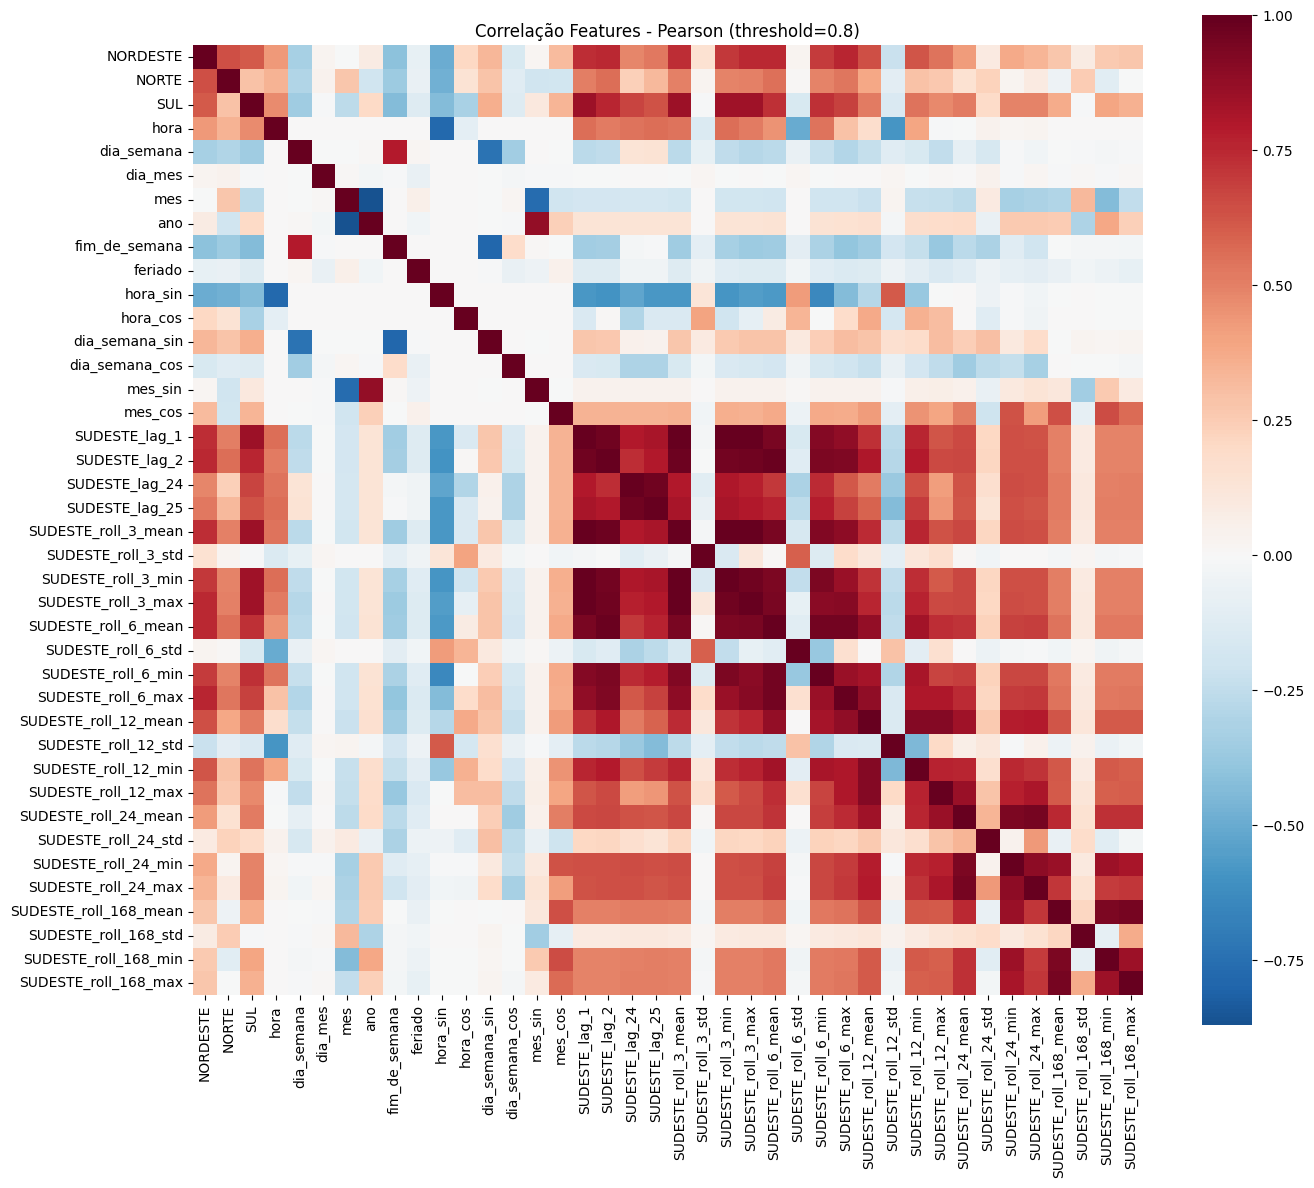


SELEÇÃO DE FEATURES RELEVANTES
Correlação mínima considerada: |corr| >= 0.3
Features removidas por multicolinearidade: 17
Features selecionadas por correlação com alvo: 26

Top features selecionadas:
   1. SUDESTE_roll_3_mean                      | corr =   0.971
   2. SUDESTE_lag_1                            | corr =   0.968
   3. SUDESTE_roll_3_min                       | corr =   0.965
   4. SUDESTE_roll_3_max                       | corr =   0.961
   5. SUL                                      | corr =   0.896
   6. SUDESTE_lag_2                            | corr =   0.889
   7. SUDESTE_roll_6_min                       | corr =   0.866
   8. SUDESTE_roll_6_mean                      | corr =   0.863
   9. SUDESTE_lag_24                           | corr =   0.821
  10. SUDESTE_roll_6_max                       | corr =   0.806
  11. SUDESTE_lag_25                           | corr =   0.788
  12. SUDESTE_roll_12_min                      | corr =   0.682
  13. NORDESTE                 

In [39]:
# 5. Feature Engineering
df_com_features = df.copy()
# 5.1 Criação de features temporais
df_com_features = criar_features_temporais(df_com_features, pais='BR')

# 5.2 Features baseadas em janelas móveis (rolling)
df_com_features = criar_features_lag_e_rolling(
    df=df_com_features,
    col_alvo=coluna_interesse,
    lags_relevantes=[1, 2, 24, 25], # da análise de ACF/PACF
    windows_curto=[3, 6, 12],
    windows_sazonal=[24, 168]
)
# 5.3 Remover linhas com NaNs causadas por lags e rolling
df_com_features = df_com_features.dropna()

# 5.4 Análise de correlação entre features
relatorio = analisar_correlacao_features(
    df=df_com_features,
    col_alvo=coluna_interesse,
    threshold=0.8,
    metodo='pearson',
    plot_tipo='heatmap',
    figsize=(14, 12),
    top_corr=10
)

# 5.5 Seleção de features relevantes
df_final = selecionar_features_relevantes(
    df=df_com_features,
    col_alvo=coluna_interesse,
    relatorio_corr=relatorio,
    corr_min=0.3,
    max_features=None
)

In [40]:
# 6. Salvamento dos dados processados
caminho_saida = ".././data/processed/carga_ons_com_features.csv"

salvar_dados_processados(
    df=df_final,
    caminho_saida=caminho_saida,
    col_alvo=coluna_interesse
)


DADOS SALVOS COM SUCESSO
Arquivo salvo em: .././data/processed/carga_ons_com_features.csv
Linhas: 8,711
Colunas: 28
Coluna alvo: SUDESTE
Features preditoras: 26
Período do índice original: 2024-07-02 01:00:00 até 2025-06-29 23:00:00

Verificação: Nenhum valor nulo encontrado.
